# CSCA 5632 Final Project: Unsupervised Fraud Detection

* This notebook applies unsupervised anomaly detection (Isolation Forest) to the Online Payments Fraud Detection dataset. The goal is to identify potentially fraudulent transactions without using the 'isFraud' label during training, treating fraud as an anomaly. The performance is then evaluated using the true labels.

*  Isolation Forest is an unsupervised machine learning algorithm that identifies anomalies or outliers in data by isolating them through a process of random partitioning within a collection of decision trees.

**Dataset:** Online Payments Fraud Detection Dataset
* **Source:** Kaggle ([https://www.kaggle.com/datasets/rupakroy/online-payments-fraud-detection-dataset](https://www.kaggle.com/datasets/rupakroy/online-payments-fraud-detection-dataset))
* **License:** CC BY-NC-SA 4.0

## Prequirements

In [1]:
%pip install kagglehub pandas numpy matplotlib seaborn scikit-learn 


[notice] A new release of pip is available: 24.0 -> 25.0.1
[notice] To update, run: python -m pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import IsolationForest
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay, precision_recall_fscore_support

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (12, 8)

## Data Preparation

### Download the dataset

In [3]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("rupakroy/online-payments-fraud-detection-dataset")

print("Path to dataset files:", path)

/Users/0xdev/.pyenv/versions/3.12.2/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /Users/0xdev/.cache/kagglehub/datasets/rupakroy/online-payments-fraud-detection-dataset/versions/1


### Load the dataset

In [4]:
df = pd.read_csv(path + "/PS_20174392719_1491204439457_log.csv")

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6362620 entries, 0 to 6362619
Data columns (total 11 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   nameOrig        object 
 4   oldbalanceOrg   float64
 5   newbalanceOrig  float64
 6   nameDest        object 
 7   oldbalanceDest  float64
 8   newbalanceDest  float64
 9   isFraud         int64  
 10  isFlaggedFraud  int64  
dtypes: float64(5), int64(3), object(3)
memory usage: 534.0+ MB



The below column reference:

* step: represents a unit of time where 1 step equals 1 hour
* type: type of online transaction
* amount: the amount of the transaction
* nameOrig: customer starting the transaction
* oldbalanceOrg: balance before the transaction
* newbalanceOrig: balance after the transaction
* nameDest: recipient of the transaction
* oldbalanceDest: initial balance of recipient before the transaction
* newbalanceDest: the new balance of recipient after the transaction
* isFraud: fraud transaction

In [6]:
df.head()

,step,type,amount,nameOrig,oldbalanceOrg,newbalanceOrig,nameDest,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
0,1,PAYMENT,9839.64,C1231006815,170136.0,160296.36,M1979787155,0.0,0.0,0,0
1,1,PAYMENT,1864.28,C1666544295,21249.0,19384.72,M2044282225,0.0,0.0,0,0
2,1,TRANSFER,181.00,C1305486145,181.0,0.00,C553264065,0.0,0.0,1,0
3,1,CASH_OUT,181.00,C840083671,181.0,0.00,C38997010,21182.0,0.0,1,0
4,1,PAYMENT,11668.14,C2048537720,41554.0,29885.86,M1230701703,0.0,0.0,0,0


In [7]:
df.describe()

,step,amount,oldbalanceOrg,newbalanceOrig,oldbalanceDest,newbalanceDest,isFraud,isFlaggedFraud
count,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06,6.362620e+06
mean,2.433972e+02,1.798619e+05,8.338831e+05,8.551137e+05,1.100702e+06,1.224996e+06,1.290820e-03,2.514687e-06
std,1.423320e+02,6.038582e+05,2.888243e+06,2.924049e+06,3.399180e+06,3.674129e+06,3.590480e-02,1.585775e-03
min,1.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
25%,1.560000e+02,1.338957e+04,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00
50%,2.390000e+02,7.487194e+04,1.420800e+04,0.000000e+00,1.327057e+05,2.146614e+05,0.000000e+00,0.000000e+00
75%,3.350000e+02,2.087215e+05,1.073152e+05,1.442584e+05,9.430367e+05,1.111909e+06,0.000000e+00,0.000000e+00
max,7.430000e+02,9.244552e+07,5.958504e+07,4.958504e+07,3.560159e+08,3.561793e+08,1.000000e+00,1.000000e+00


In [8]:
# Check for missing values
print(df.isnull().sum())

step              0
type              0
amount            0
nameOrig          0
oldbalanceOrg     0
newbalanceOrig    0
nameDest          0
oldbalanceDest    0
newbalanceDest    0
isFraud           0
isFlaggedFraud    0
dtype: int64


In [9]:
# Analyze Target Variable ('isFraud') - Crucial for understanding anomaly rate (it usually comes from the previous experience in the real world)
print("\nDistribution of 'isFraud' label:")
fraud_counts = df['isFraud'].value_counts()
print(fraud_counts)
fraud_percentage = (fraud_counts[1] / df.shape[0]) * 100
print(f"\nPercentage of fraudulent transactions: {fraud_percentage:.4f}%")


Distribution of 'isFraud' label:
isFraud
0    6354407
1       8213
Name: count, dtype: int64

Percentage of fraudulent transactions: 0.1291%


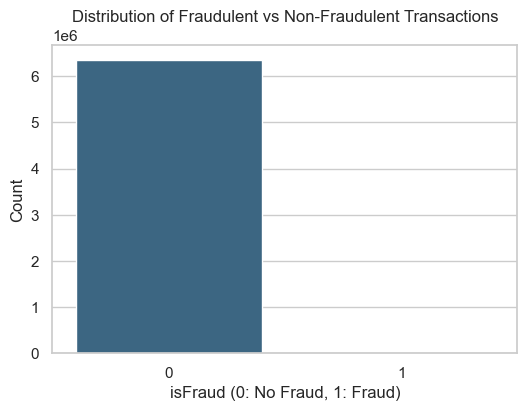

In [36]:
# Visualize imbalance
plt.figure(figsize=(6, 4))
sns.countplot(x='isFraud', data=df, palette='viridis', hue='isFraud', legend=False)
plt.title('Distribution of Fraudulent vs Non-Fraudulent Transactions')
plt.xlabel('isFraud (0: No Fraud, 1: Fraud)')
plt.ylabel('Count')
plt.show()

type
CASH_OUT    2237500
PAYMENT     2151495
CASH_IN     1399284
TRANSFER     532909
DEBIT         41432
Name: count, dtype: int64


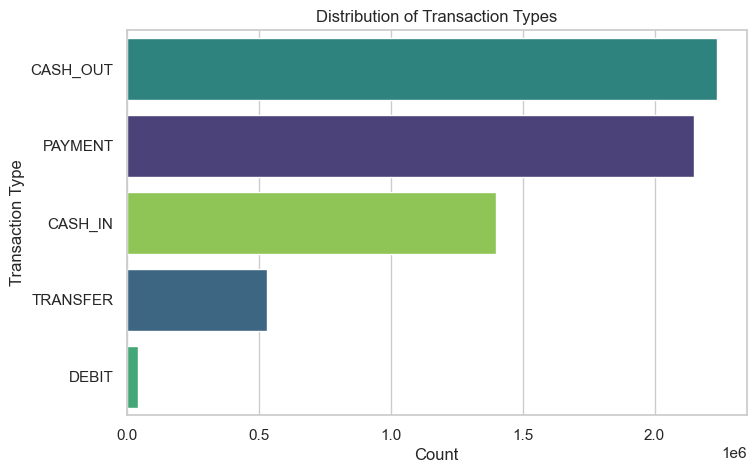

In [33]:
# Analyze Transaction Type ('type')

print(df['type'].value_counts())

plt.figure(figsize=(8, 5))
sns.countplot(y='type', data=df, order = df['type'].value_counts().index, palette='viridis', hue='type', legend=False)
plt.title('Distribution of Transaction Types')
plt.xlabel('Count')
plt.ylabel('Transaction Type')
plt.show()

In [12]:
# Check which transaction types contain fraud
print("\nFraud counts by Transaction Type:")
print(df.groupby('type')['isFraud'].sum())


Fraud counts by Transaction Type:
type
CASH_IN        0
CASH_OUT    4116
DEBIT          0
PAYMENT        0
TRANSFER    4097
Name: isFraud, dtype: int64


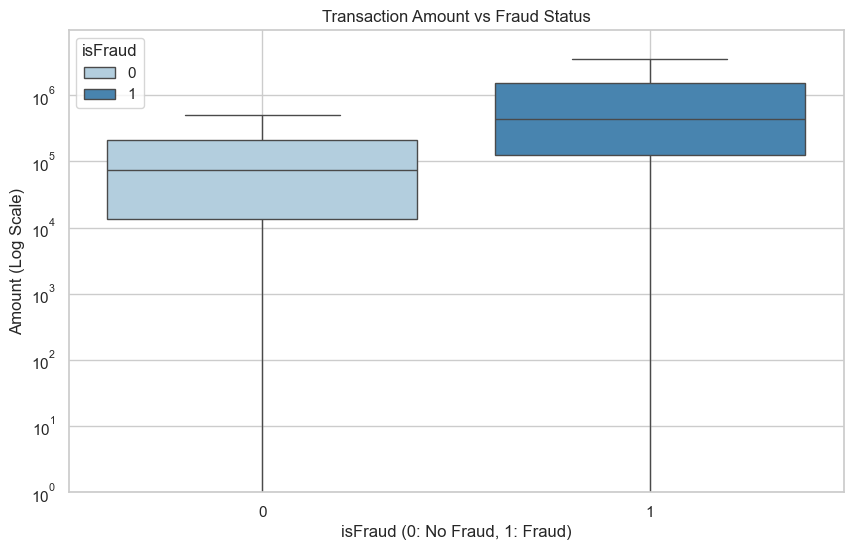

In [31]:
# Analyze Transaction Amount ('amount')

# Compare amount distributions for fraud vs non-fraud
plt.figure(figsize=(10, 6))
sns.boxplot(x='isFraud', y='amount', data=df, palette='Blues', showfliers=False, hue='isFraud', legend=True)
plt.title('Transaction Amount vs Fraud Status')
plt.xlabel('isFraud (0: No Fraud, 1: Fraud)')
plt.ylabel('Amount (Log Scale)')
plt.yscale('log') # Use log scale for y-axis
plt.ylim(bottom=1) # Avoid log(0) issues
plt.grid(True)
plt.show()

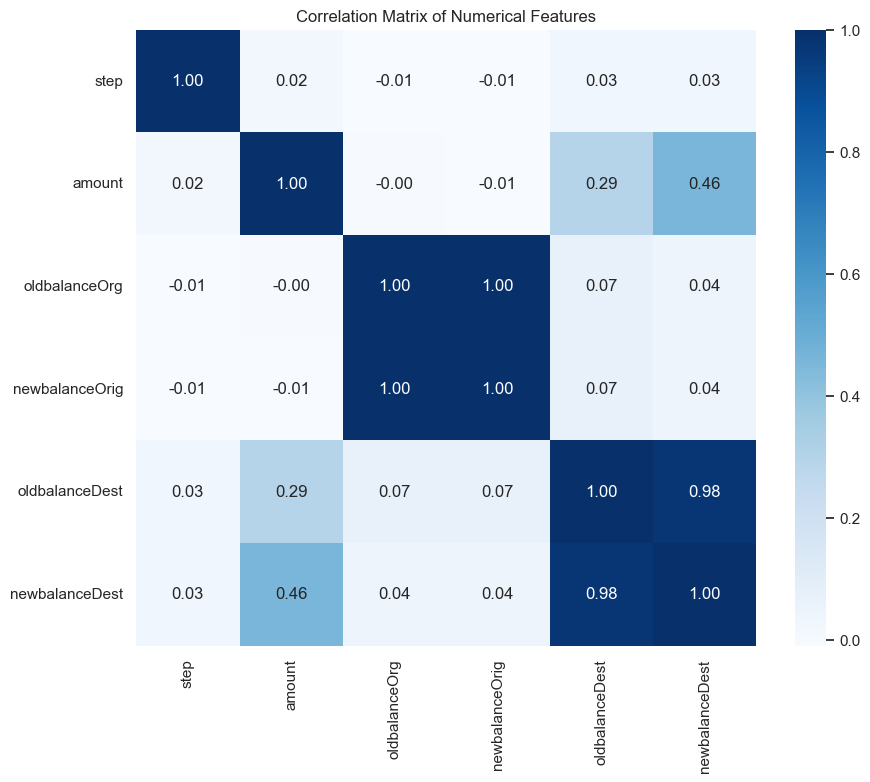

In [28]:
# Analyze Correlations (Numerical Features Only)
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
# Remove boolean-like flags often treated as numerical if not desired in correlation
numerical_cols = [col for col in numerical_cols if col not in ['isFraud', 'isFlaggedFraud']]

plt.figure(figsize=(10, 8))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='Blues', fmt=".2f")
plt.title('Correlation Matrix of Numerical Features')
plt.show()

**EDA Summary:**
- The dataset is large with 6362620 rows and clean.
- Fraud transactions are rare, with only 0.17% of the data being fraudulent.
- Fraude transactions are only occurred in the "CASH_OUT" and "TRANSFER" transaction types.
- New balance and old balance features are highly correlated.

### Data Cleaning

In [ ]:
# Remove unnecessary columns
df_processed = df.drop(['nameOrig', 'nameDest', 'isFlaggedFraud', 'newbalanceOrig', 'newbalanceDest'], axis=1)
df_processed = df_processed[df_processed['type'].isin(['TRANSFER', 'CASH_OUT'])].copy()

In [16]:
df_processed.info()

<class 'pandas.core.frame.DataFrame'>
Index: 2770409 entries, 2 to 6362619
Data columns (total 6 columns):
 #   Column          Dtype  
---  ------          -----  
 0   step            int64  
 1   type            object 
 2   amount          float64
 3   oldbalanceOrg   float64
 4   oldbalanceDest  float64
 5   isFraud         int64  
dtypes: float64(3), int64(2), object(1)
memory usage: 148.0+ MB


In [17]:
print("\nDistribution of 'isFraud' label:")
fraud_counts = df_processed['isFraud'].value_counts()
print(fraud_counts)
fraud_percentage = (fraud_counts[1] / df_processed.shape[0]) * 100
print(f"\nPercentage of fraudulent transactions: {fraud_percentage:.4f}%")


Distribution of 'isFraud' label:
isFraud
0    2762196
1       8213
Name: count, dtype: int64

Percentage of fraudulent transactions: 0.2965%


- Split the dataset into training and testing sets.
- Remove the `isFraud` column from the training set.

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    df_processed.drop('isFraud', axis=1),
    df_processed['isFraud'],
    test_size=0.3,
    random_state=42,
    stratify=df_processed['isFraud']  # Maintain fraud distribution
)

- Identify numerical and categorical features

In [ ]:
numerical_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(include='object').columns.tolist()

print(f"\nNumerical Features: {numerical_features}")
print(f"Categorical Features: {categorical_features}")


Numerical Features: ['step', 'amount', 'oldbalanceOrg', 'oldbalanceDest']
Categorical Features: ['type']


- Scale the features

In [20]:
# Create preprocessing pipelines for numerical and categorical features
# Numerical: Scale using StandardScaler
# Categorical: Encode using OneHotEncoder (handle unknown values if any might appear in new data)

from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

numerical_pipeline = Pipeline([
    ('scaler', StandardScaler())
])

categorical_pipeline = Pipeline([
    ('onehot', OneHotEncoder(handle_unknown='ignore'))
])

# Combine pipelines using ColumnTransformer
preprocessor = ColumnTransformer([
    ('num', numerical_pipeline, numerical_features),
    ('cat', categorical_pipeline, categorical_features)
], remainder='passthrough') # Keep other columns if any (shouldn't be any here)

# Apply preprocessing
print("\nApplying preprocessing (scaling numerical, one-hot encoding categorical)...")

# Fit and transform the features
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print(f"Processed feature matrix shape for X_train: {X_train_processed.shape}") # Shape might change
print(f"Processed feature matrix shape for X_test: {X_test_processed.shape}") # Shape might change


Applying preprocessing (scaling numerical, one-hot encoding categorical)...
Processed feature matrix shape for X_train: (1939286, 6)
Processed feature matrix shape for X_test: (831123, 6)


In [21]:
X_train_processed[:5] # Display first 5 rows of processed features    

array([[ 0.72772782, -0.17416169,  0.46139634, -0.32685876,  1.        ,
         0.        ],
       [-1.63170771,  0.1522994 ,  0.21307556, -0.40128046,  1.        ,
         0.        ],
       [ 2.45845149, -0.17952776, -0.16193532, -0.39168651,  1.        ,
         0.        ],
       [ 0.28974877, -0.34945403,  0.86840823, -0.38290605,  1.        ,
         0.        ],
       [ 0.96084571, -0.09287811, -0.19476423,  0.92154181,  1.        ,
         0.        ]])

## Model Training

### Apply the Isolation Forest algorithm to identify anomalies (potential fraud).

In [ ]:

print("\nTraining Isolation Forest model...")
# contamination_value = 'auto' # make it purely unsupervised
contamination_value = float(fraud_percentage / 100) # Use known rate (slightly less unsupervised)

iso_forest = IsolationForest(n_estimators=100,
                             contamination=contamination_value,
                            #  max_samples=256,
                             random_state=42,
                             n_jobs=-1)

iso_forest.fit(X_train_processed)

print("Isolation Forest model fitted.")


Training Isolation Forest model...
Isolation Forest model fitted.


### Predict anomalies (potential fraud) in the test set.

In [ ]:
# predict() returns +1 for inliers (normal) and -1 for outliers (anomalies)
print("\nPredicting anomalies...")
predictions_raw = iso_forest.predict(X_test_processed)

# Convert predictions: 1 for anomaly (fraud), 0 for normal
y_pred_unsupervised = np.where(predictions_raw == -1, 1, 0)

print("Predictions generated (1: predicted anomaly/fraud, 0: predicted normal).")
print("Number of anomalies detected:", np.sum(y_pred_unsupervised == 1))


Predicting anomalies...
Predictions generated (1: predicted anomaly/fraud, 0: predicted normal).
Number of anomalies detected: 2492


In [48]:
X_data = X_test.copy()
X_data['anomaly_score'] = iso_forest.decision_function(X_test_processed)
X_data['anomaly'] = predictions_raw
X_data['anomaly'].value_counts()

anomaly
 1    828631
-1      2492
Name: count, dtype: int64

### Evaluate the model

/Users/0xdev/.pyenv/versions/3.12.2/lib/python3.12/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


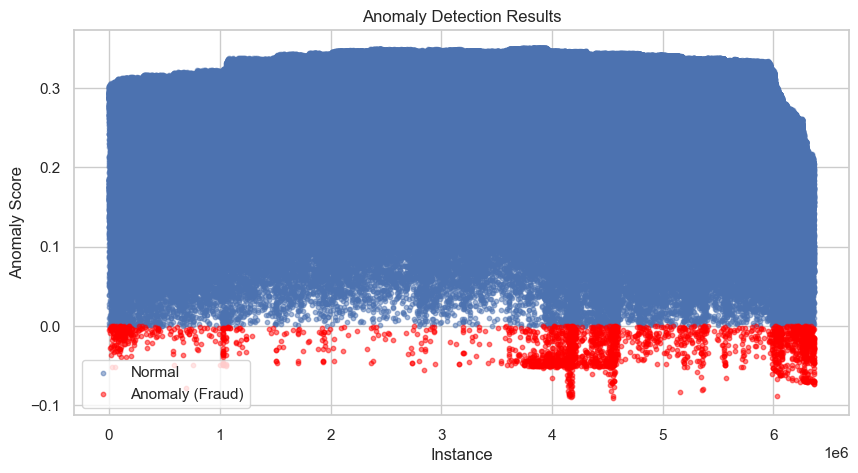

In [49]:
# Visualization of the results
plt.figure(figsize=(10, 5))

# Plot normal instances
normal = X_data[X_data['anomaly'] == 1]
plt.scatter(normal.index, normal['anomaly_score'], label='Normal', alpha=0.5, s=10) # Use alpha/smaller size for large data

# Plot anomalies
anomalies = X_data[X_data['anomaly'] == -1]
plt.scatter(anomalies.index, anomalies['anomaly_score'], label='Anomaly (Fraud)', color='red', alpha=0.5, s=10)
plt.xlabel("Instance")
plt.ylabel("Anomaly Score")
plt.title("Anomaly Detection Results")
plt.legend()
plt.grid(True)
plt.show()

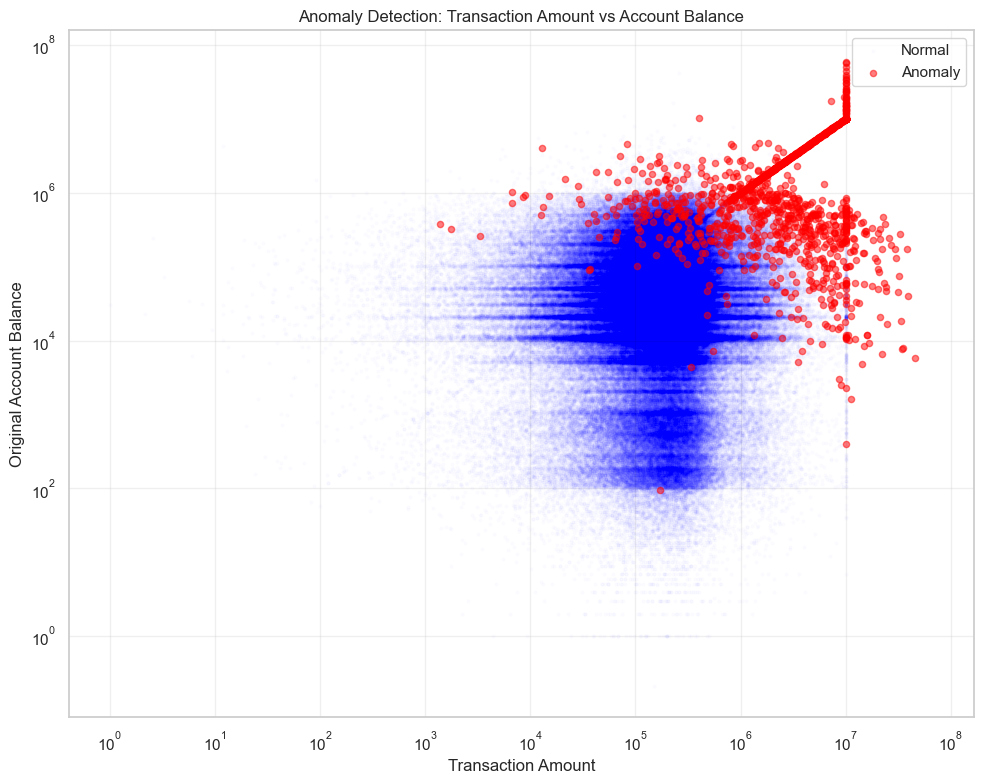

In [50]:
# Visualization of the results - comparing amount vs balance for normal/anomalous transactions
plt.figure(figsize=(10, 8))

# Plot non-anomalies with transparency (there are many)
plt.scatter(normal['amount'], normal['oldbalanceOrg'], 
            label='Normal', alpha=0.01, s=5, color='blue')

# Plot anomalies with higher visibility
plt.scatter(anomalies['amount'], anomalies['oldbalanceOrg'], 
            label='Anomaly', alpha=0.5, s=20, color='red')

plt.xlabel("Transaction Amount")
plt.ylabel("Original Account Balance")
plt.title("Anomaly Detection: Transaction Amount vs Account Balance")
plt.xscale('log')  # Log scale for better visualization of amount ranges
plt.yscale('log')  # Log scale for better visualization of balance ranges
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()


--- Evaluation Report (Unsupervised Anomalies vs True Fraud Labels) ---

Confusion Matrix:


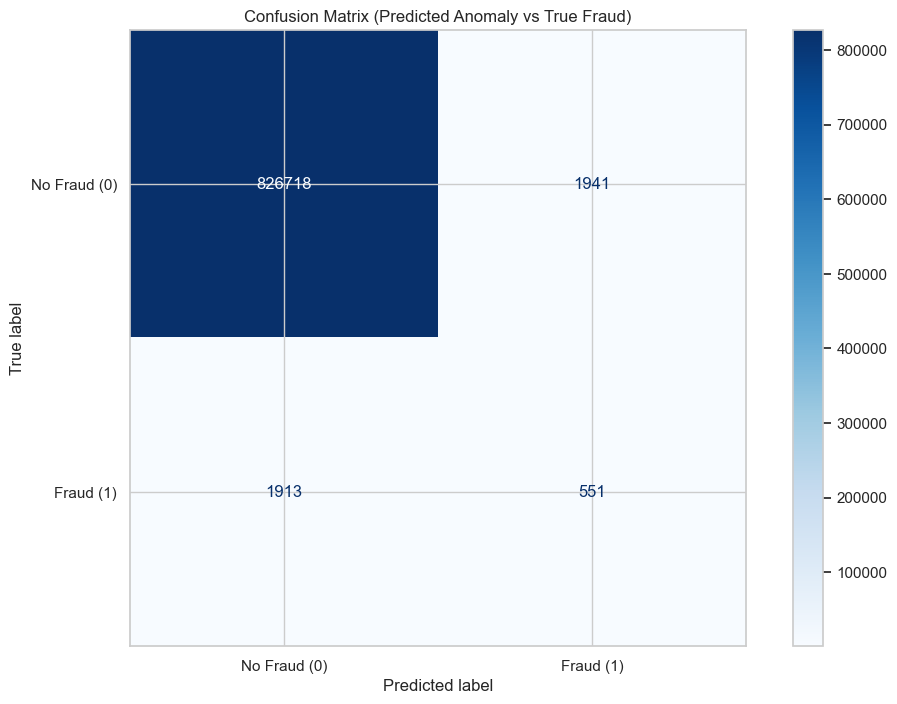


Classification Report:
              precision    recall  f1-score   support

No Fraud (0)     0.9977    0.9977    0.9977    828659
   Fraud (1)     0.2211    0.2236    0.2224      2464

    accuracy                         0.9954    831123
   macro avg     0.6094    0.6106    0.6100    831123
weighted avg     0.9954    0.9954    0.9954    831123


Metrics for Fraud Class (1):
  Precision: 0.2211
  Recall:    0.2236
  F1-Score:  0.2224


In [47]:

# Evaluate the performance of the unsupervised anomaly detection against the true `isFraud` labels. Focus on metrics relevant for imbalanced data and fraud detection (Precision, Recall, F1 for the fraud class).

print("\n--- Evaluation Report (Unsupervised Anomalies vs True Fraud Labels) ---")

# Compare y_pred_unsupervised (from Isolation Forest) with y (true labels)
print("\nConfusion Matrix:")
cm = confusion_matrix(y_test, y_pred_unsupervised)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Fraud (0)', 'Fraud (1)'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix (Predicted Anomaly vs True Fraud)')
plt.show()

print("\nClassification Report:")
report = classification_report(y_test, y_pred_unsupervised, target_names=['No Fraud (0)', 'Fraud (1)'], digits=4)
print(report)

# Extract key metrics for the fraud class (class 1)
precision, recall, f1, _ = precision_recall_fscore_support(y_test, y_pred_unsupervised, average=None, labels=[1])
print(f"\nMetrics for Fraud Class (1):")
print(f"  Precision: {precision[0]:.4f}")
print(f"  Recall:    {recall[0]:.4f}") # How many actual frauds were detected?
print(f"  F1-Score:  {f1[0]:.4f}")

### Summarize the results

- **High Accuracy, Misleadings:**: The overall accuracy of the model is very high(99.54%). However, the dataset is imbalanced, with only 0.17% of the data being fraudulent. This means that the model could be predicting the majority class (non-fraudulent transactions) most of the time, leading to misleading accuracy.
- **Excellent Performance on "Normal (No Fraud)" Transactions:**: The model correctly identifies non-fraudulent transactions with a high accuracy (Precision, Recall, F1-score are 0.9977). This indicates that the model is effective in recognizing normal transactions.
- **Low Performance on "Fraud" Transactions:**: The model has a low precision (0.2211), recall (0.2236) and f1-score (0.2224) for fraudulent transactions, indicating that it is not effective in identifying fraud. This is likely due to the imbalanced nature of the dataset, where fraudulent transactions are rare.

## Conclusion

* This project aimed to detect fraudulent online payments using unsupervised anomaly detection. 

* EDA revealed a highly imbalanced dataset where fraud primarily occurred in 'TRANSFER' and 'CASH_OUT' transactions. 

* The data was preprocessed by scaling numerical features and one-hot encoding the transaction type. 

* An Isolation Forest model was trained on these features *without* using the fraud labels. The model identified transactions deviating from the norm as anomalies.

* The Isolation Forest successfully identified a portion of the fraudulent transactions based solely on feature patterns, demonstrating the feasibility of unsupervised detection.

* Unsupervised methods often generate more false positives than tuned supervised models, as they flag *any* deviation, not just patterns explicitly learned from labeled fraud 
examples.

* The features used might not perfectly capture all fraudulent behaviors. More sophisticated feature engineering could potentially improve results.

